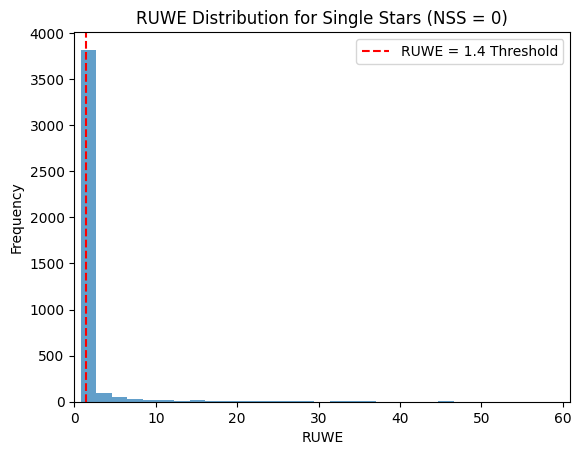

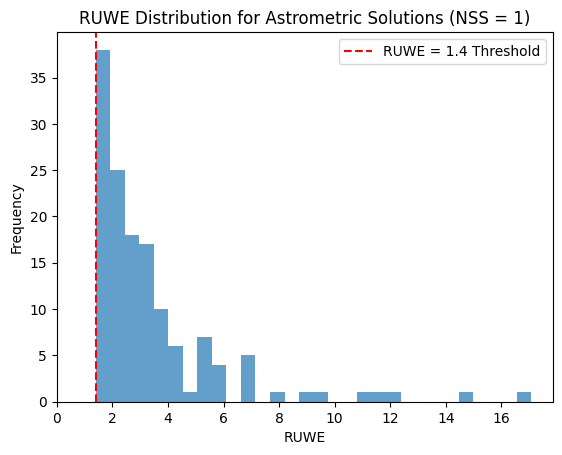

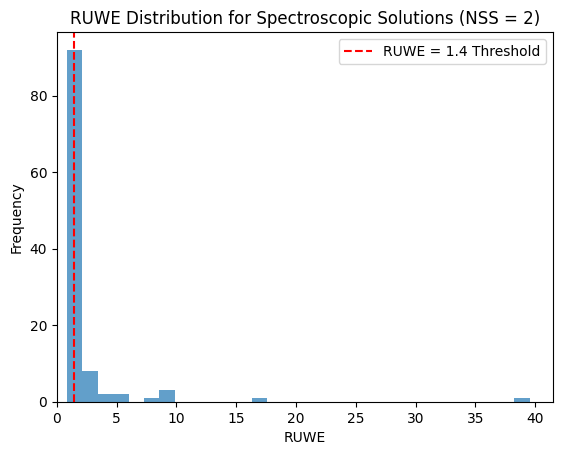

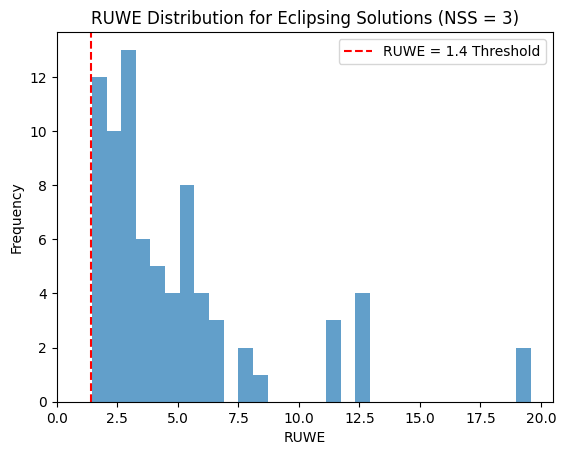

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_cut_1 = "ASTR426_BinaryData_APOGEE_Cut_1.csv"
file_cut_2 = "ASTR426_BinaryData_APOGEE_Cut_2_Small.csv"

#combine files
df_cut_1 = pd.read_csv(file_cut_1)
df_cut_2 = pd.read_csv(file_cut_2)
df_combined = pd.concat([df_cut_1, df_cut_2], ignore_index=True)

def ruwe_single_star(df):
    single_star = df[df['non_single_star'] == 0]
    plt.hist(single_star['RUWE'], bins=30, alpha=0.7)
    plt.axvline(x=1.4, color='red', linestyle='--', label='RUWE = 1.4 Threshold')
    plt.legend()
    plt.xlabel('RUWE')
    plt.ylabel('Frequency')
    plt.title('RUWE Distribution for Single Stars (NSS = 0)')
    plt.xlim(left=0)
    plt.show()

ruwe_single_star(df_combined)

def ruwe_astrometric(df):
    astrometric = df[df['non_single_star'] == 1]
    plt.hist(astrometric['RUWE'], bins=30, alpha=0.7)
    plt.axvline(x=1.4, color='red', linestyle='--', label='RUWE = 1.4 Threshold')
    plt.legend()
    plt.xlabel('RUWE')
    plt.ylabel('Frequency')
    plt.title('RUWE Distribution for Astrometric Solutions (NSS = 1)')
    plt.xlim(left=0)
    plt.show()
    
ruwe_astrometric(df_combined)

def ruwe_spectroscopic(df):
    spectroscopic = df[df['non_single_star'] == 2]
    plt.hist(spectroscopic['RUWE'], bins=30, alpha=0.7)
    plt.axvline(x=1.4, color='red', linestyle='--', label='RUWE = 1.4 Threshold')
    plt.legend()
    plt.xlabel('RUWE')
    plt.ylabel('Frequency')
    plt.title('RUWE Distribution for Spectroscopic Solutions (NSS = 2)')
    plt.xlim(left=0)
    plt.show()
    
ruwe_spectroscopic(df_combined)

def ruwe_eclipsing_combined(df):
    eclipsing = df[df['non_single_star'] == 3]
    plt.hist(eclipsing['RUWE'], bins=30, alpha=0.7)
    plt.axvline(x=1.4, color='red', linestyle='--', label='RUWE = 1.4 Threshold')
    plt.legend()
    plt.xlabel('RUWE')
    plt.ylabel('Frequency')
    plt.title('RUWE Distribution for Eclipsing Solutions (NSS = 3)')
    plt.xlim(left=0)
    plt.show()
    
ruwe_eclipsing_combined(df_combined)

In [6]:
# Print number of stars with RUWE > 1.4 for each category
def count_ruwe_above_threshold(df, nss_value):
    category = df[df['non_single_star'] == nss_value]
    count_above_threshold = (category['RUWE'] > 1.4).sum()
    return count_above_threshold

categories = {0: 'Single Stars', 1: 'Astrometric Solutions', 2: 'Spectroscopic Solutions', 3: 'Eclipsing Solutions'}
for nss_value, category_name in categories.items():
    count = count_ruwe_above_threshold(df_combined, nss_value)
    total = (df_combined['non_single_star'] == nss_value).sum()
    percentage = (count / total) * 100 if total > 0 else 0
    print(f"{category_name}: {count} stars with RUWE > 1.4 ({percentage:.2f}%)")

Single Stars: 603 stars with RUWE > 1.4 (14.24%)
Astrometric Solutions: 139 stars with RUWE > 1.4 (100.00%)
Spectroscopic Solutions: 37 stars with RUWE > 1.4 (33.64%)
Eclipsing Solutions: 77 stars with RUWE > 1.4 (100.00%)
